In [25]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Conv1D, MaxPooling1D, UpSampling1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from keras_tuner.tuners import BayesianOptimization
from sklearn.metrics import mean_squared_error
from keras_tuner import HyperModel

from datetime import datetime
import pickle

## LOADING DATASET

In [29]:
# LOADING DATASET

PATH_TRAINING_A = '../data/preprocessing/normalized/normalized_local_original.npy'
lines_a_noisy = np.load(PATH_TRAINING_A)

train_norm, temp = train_test_split(lines_a_noisy, test_size=0.4, random_state=42)  # 40% for val+test
val_norm, test_norm = train_test_split(temp, test_size=0.25, random_state=42)   

print(f'Train Shape {train_norm.shape}, Val Shape {val_norm.shape}, Test Shape {test_norm.shape}')

Train Shape (41116, 64, 2), Val Shape (20559, 64, 2), Test Shape (6853, 64, 2)


## BUILDING AUTOENCODER ARCHITECTURE

In [30]:
#AE ARCHITECTURE

timesteps = 64
features = 2
latent_dim = 32  #Adjust for tighter bottleneck

inputs = Input(shape=(timesteps, features))

encoded = Bidirectional(LSTM(128, return_sequences=True))(inputs)
encoded = LSTM(64, return_sequences=True)(encoded)
encoded = LSTM(latent_dim)(encoded)

decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, return_sequences=True)(decoded)
decoded = LSTM(128, return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features))(decoded)

lstm_autoencoder = Model(inputs, decoded)
#autoencoder.summary()


## MODEL TRAINING

In [31]:
#TRAINING SETUP 

description = 'huber_local_finetuned_bidrectional'
epochs = 50
batch_size = 32
loss = 'huber' #mse, mae

early_stop = EarlyStopping(
    monitor='val_loss',     # what to watch
    patience=10,            # epochs to wait for improvement
    restore_best_weights=True   
)

log_dir = "../checkpoints/autoencoder/logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# metrics: things to be observed, loss: what is actually used for learning
lstm_autoencoder.compile(optimizer='adam', loss=loss, metrics=['accuracy','mse', 'mae'])

In [32]:
#TRAINING

timestamp = datetime.now().strftime('%d%m_%H%M')

history = lstm_autoencoder.fit(
    train_norm, train_norm,
    validation_data=(val_norm, val_norm),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=[early_stop, tensorboard_callback]
)


Epoch 1/50
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 210s 160ms/step - accuracy: 0.9634 - loss: 0.0035 - mae: 0.0493 - mse: 0.0071 - val_accuracy: 0.9757 - val_loss: 7.4441e-04 - val_mae: 0.0263 - val_mse: 0.0015
Epoch 2/50
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 202s 157ms/step - accuracy: 0.9811 - loss: 6.1638e-04 - mae: 0.0246 - mse: 0.0012 - val_accuracy: 0.9867 - val_loss: 3.9754e-04 - val_mae: 0.0193 - val_mse: 7.9511e-04
Epoch 3/50
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 198s 154ms/step - accuracy: 0.9852 - loss: 3.7728e-04 - mae: 0.0194 - mse: 7.5457e-04 - val_accuracy: 0.9865 - val_loss: 3.0948e-04 - val_mae: 0.0175 - val_mse: 6.1897e-04
Epoch 4/50
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 195s 152ms/step - accuracy: 0.9866 - loss: 2.9998e-04 - mae: 0.0173 - mse: 5.9996e-04 - val_accuracy: 0.9880 - val_loss: 2.8748e-04 - val_mae: 0.0173 - val_mse: 5.7496e-04
Epoch 5/50
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 197s 153ms/step - accuracy: 0.9869 - loss: 2.8819e-04 - mae: 0.0169 - mse: 5.7638e-04 - val_accuracy: 0.9900 - val_los

In [37]:
%reload_ext tensorboard
%tensorboard --logdir ../checkpoints/autoencoder/logs

Reusing TensorBoard on port 6008 (pid 19612), started 0:01:14 ago. (Use '!kill 19612' to kill it.)

In [43]:
# TRAINING HISTORY 

def plot_history(history, epochs, batch_size, train_data_noisy):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='#143642')

    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='#EC9A29')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Training Loss LSTM AE {epochs} Epochs {batch_size} Batches and Training Data Shape: {train_data_noisy.shape}')
    plt.grid()
    
    # save figure 
    save_path = f'../checkpoints/autoencoder/history/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

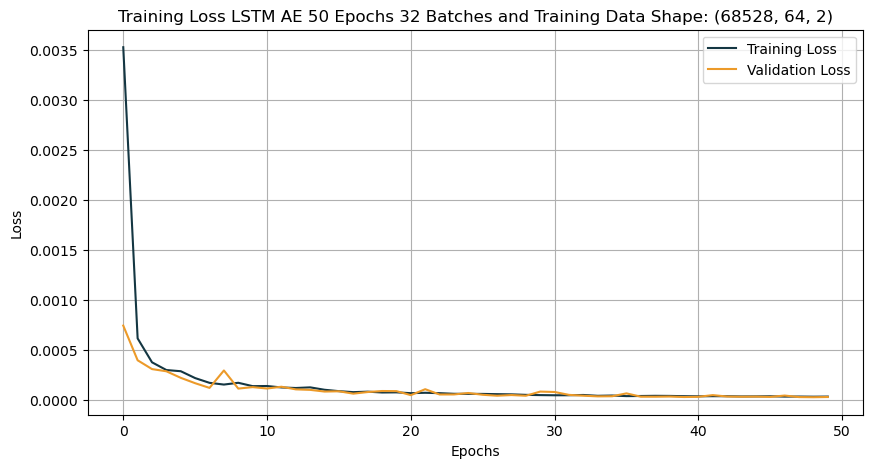

In [44]:
plot_history(history, epochs, batch_size, lines_a_noisy)

In [36]:
# SAVING MODEL, WEIGHTS, HISTORY
lstm_autoencoder.save(f'../checkpoints/autoencoder/model/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.keras')
lstm_autoencoder.save_weights(f'../checkpoints/autoencoder/weights/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.weights.h5')
np.save(f'../checkpoints/autoencoder/history/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.npy', history.history)

## POST TRAINING

In [40]:
# PREDICTION
#lstm_autoencoder = tf.keras.models.load_model(f'../checkpoints/autoencoder/model/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.keras')
reconstructed = lstm_autoencoder.predict(test_norm)

215/215 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step


In [41]:
# SAVING PREDICTION 

with open(f'../data/results/lstm_autoencoder/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs_predictions.pkl', 'wb') as f:
    pickle.dump(reconstructed, f)

In [1]:
# PLOT PREDICTION

for i in range(100,120):
    plt.figure(figsize=(8,7))
    plt.plot(test_norm[i,:,0], test_norm[i,:,1], color='#EC9A29', label='Original')
    plt.plot(reconstructed[i,:,0], reconstructed[i,:,1], color='#143642', label='Reconstructed')
    plt.legend()
    #plt.axis('equal')
    plt.grid(True)
    plt.title('LSTM AE')
    plt.show()


NameError: name 'plt' is not defined

## HYPERPARAMETER OPTIMIZATION

In [ ]:
num_points = 64
coordinates = 2

def build_model(hp):

    latent_dim = hp.Int('latent_dim', min_value=8, max_value=64, step=8)

    # LSTM layer sizes
    enc1 = hp.Int('enc_lstm1', min_value=64, max_value=256, step=64)
    enc2 = hp.Int('enc_lstm2', min_value=32, max_value=128, step=32)
    dec1 = hp.Int('dec_lstm1', min_value=32, max_value=128, step=32)
    dec2 = hp.Int('dec_lstm2', min_value=64, max_value=256, step=64)

    # Learning rate
    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')

    # Loss type
    loss = hp.Choice('loss', ['mse', 'mae', 'huber'])

    inputs = Input(shape=(num_points, coordinates))

    # ENCODER
    x = LSTM(enc1, return_sequences=True)(inputs)
    x = LSTM(enc2, return_sequences=True)(x)
    encoded = LSTM(latent_dim)(x)

    # DECODER
    x = RepeatVector(num_points)(encoded)
    x = LSTM(dec1, return_sequences=True)(x)
    x = LSTM(dec2, return_sequences=True)(x)
    outputs = TimeDistributed(Dense(coordinates))(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=loss,
        metrics=['mse', 'mae']
    )

    return model

In [ ]:
tuner = BayesianOptimization(
    hypermodel=build_model,
    objective='val_loss',
    max_trials=8,          
    num_initial_points=5,  
    directory= '../checkpoints/autoencoder/', 
    project_name='tuner_results'
)

In [ ]:
tuner.search(
    train_norm, train_norm,
    validation_data=(val_norm, val_norm),
    epochs=50,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]
)

In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.get_best_models(1)[0]

print('Best hyperparameters:')
for p, v in best_hp.values.items():
    print(p, '=', v)


In [ ]:
history = best_model.fit(
    train_norm, train_norm,
    validation_data=(val_norm, val_norm),
    epochs=150,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)]
)
